In [258]:
import pandas as pd
import numpy as np
import joblib
import shap

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [259]:
# Load model & config
encoder15 = load_model("encoder_15.keras")

xgb_15 = joblib.load("xgb_churn_15.pkl")

scaler = joblib.load("scaler_15.pkl")

FEATURE_COLS = joblib.load("feature_cols.pkl")

In [260]:
# file dự đoán
df_full = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df7_10orders.csv",parse_dates=["syncdate"])
df_full15 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df8_10orders.csv",parse_dates=["syncdate"])
df_full15r = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df9_10orders.csv",parse_dates=["syncdate"])
# df_full4 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df4_10orders.csv",parse_dates=["syncdate"])
# df_full5 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df5_10orders.csv",parse_dates=["syncdate"])
# df_full6 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df6_10orders.csv",parse_dates=["syncdate"])

# ==== GIỮ BẢN RAW (CHƯA SCALE) ====
df_raw = df_full.copy()
df_raw15 = df_full15.copy()
df_raw15r = df_full15r.copy()
# df_raw30 = df_full30.copy()
# df_raw301 = df_full301.copy()
# df_raw30r = df_full30r.copy()


# Loại dữ liệu sai nếu cần
df_full = df_full[df_full["remainingpoint"] >= 0].copy()
df_full15 = df_full15[df_full15["remainingpoint"] >= 0].copy()
df_full15r = df_full15r[df_full15r["remainingpoint"] >= 0].copy()
# df_full30 = df_full30[df_full30["remainingpoint"] >= 0].copy()
# df_full301 = df_full301[df_full301["remainingpoint"] >= 0].copy()
# df_full30r = df_full30r[df_full30r["remainingpoint"] >= 0].copy()

# Ghép file
df_full = df_full.sort_values(["spbiid", "syncdate"])
df_full15 = df_full15.sort_values(["spbiid", "syncdate"])
df_full15r = df_full15r.sort_values(["spbiid", "syncdate"])
# df_full30 = df_full30.sort_values(["spbiid", "syncdate"])
# df_full301 = df_full301.sort_values(["spbiid", "syncdate"])
# df_full30r = df_full30r.sort_values(["spbiid", "syncdate"])

df_full[FEATURE_COLS] = scaler.transform(df_full[FEATURE_COLS])
df_full15[FEATURE_COLS] = scaler.transform(df_full15[FEATURE_COLS])
df_full15r[FEATURE_COLS] = scaler.transform(df_full15r[FEATURE_COLS])
# df_full30[FEATURE_COLS] = scaler_30.transform(df_full30[FEATURE_COLS])
# df_full301[FEATURE_COLS] = scaler_30.transform(df_full301[FEATURE_COLS])
# df_full30r[FEATURE_COLS] = scaler_30.transform(df_full30r[FEATURE_COLS])


C:\Users\nguye\AppData\Local\Temp\ipykernel_4200\1137342008.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_full = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df7_10orders.csv",parse_dates=["syncdate"])
C:\Users\nguye\AppData\Local\Temp\ipykernel_4200\1137342008.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_full15 = pd.read_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\needprediction\29_01\df8_10orders.csv",parse_dates=["syncdate"])
C:\Users\nguye\AppData\Local\Temp\ipykernel_4200\1137342008.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure 

In [261]:
df_full

,syncdate,spbiid,totalcompleted,copoorder,incopoorder,ordercycletime,copoavg,startpercent,curpercent,uplevelamount,...,eventtotalearned,corpominuspoint,remainingpoint,spccid,delaybinnoise,lastordertime,returnamount,churnwindow,ischurn,nextdays
0,1759251600,1355,1.622488,1.186664,1.968015,-0.068315,-0.578103,-0.726430,-0.231499,1.610744,...,0.969678,-0.077467,1.012198,-0.426167,1.85,1751535000,2,60,1,15
1,1760461200,1355,1.622488,1.186664,1.968015,-0.068315,-0.578103,-0.726430,-0.231499,1.610744,...,0.969678,-0.077467,1.012198,-0.426167,2.14,1751535000,2,60,1,15
2,1761930000,1355,1.622488,1.186664,1.968015,-0.068315,-0.578103,-0.726430,-0.231499,1.610744,...,0.969678,-0.077467,1.012198,-0.426167,2.49,1751535000,2,60,1,15
3,1759251600,16026,1.213988,1.688173,-0.483369,-0.179196,0.802110,-0.726430,0.799049,1.610744,...,-0.448247,-0.077467,0.356471,0.198004,4.14,1743728400,2,60,1,15
4,1760461200,16026,1.213988,1.688173,-0.483369,-0.179196,0.802110,-0.726430,0.799049,1.610744,...,-0.448247,-0.077467,0.356471,0.198004,4.46,1743728400,2,60,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,1760461200,32672,1.418238,1.938928,-0.483369,-0.575191,0.426324,0.353676,-0.231499,-0.828023,...,2.754450,-0.077467,2.659099,0.198004,1.32,1757496600,0,60,0,15
62,1761930000,32672,1.418238,1.938928,-0.483369,-0.575191,0.426324,0.353676,-0.231499,-0.828023,...,2.754450,-0.077467,2.659099,0.198004,1.97,1757496600,0,60,0,15
63,1759251600,34323,1.213988,1.437419,0.129477,-0.757132,1.095381,-0.726430,0.799049,1.610744,...,2.754450,-0.077467,3.788499,0.198004,1.18,1757412000,0,60,0,15
64,1760461200,34323,1.213988,1.437419,0.129477,-0.757132,1.095381,-0.726430,0.799049,1.610744,...,2.754450,-0.077467,3.788499,0.198004,1.96,1757412000,0,60,0,15


In [262]:
# Build sliding window cho LSTM
def build_sequences(df, feature_cols, max_steps=3):
    X_seq, X_last, spbiids = [], [], []

    df = df.sort_values("syncdate")

    for spbiid, g in df.groupby("spbiid"):
        g = g.sort_values("syncdate")
        seq = g[feature_cols].values.astype("float32")

        hist = seq[-max_steps:]
        X_seq.append(hist)
        X_last.append(seq[-1])
        spbiids.append(spbiid)

    X_seq = pad_sequences(
        X_seq,
        maxlen=max_steps,
        padding="pre",
        dtype="float32"
    )

    X_last = np.asarray(X_last, dtype="float32")

    return X_seq, X_last, spbiids

X_seq, X_last, spbiids = build_sequences(df_full, FEATURE_COLS, 3)
X_seq15, X_last15, spbiids15 = build_sequences(df_full15, FEATURE_COLS, 3)
X_seq15r, X_last15r, spbiids15r = build_sequences(df_full15r, FEATURE_COLS, 3)
# X_seq30, X_last30, spbiids30 = build_sequences(df_full30, FEATURE_COLS, 3)
# X_seq301, X_last301, spbiids301 = build_sequences(df_full301, FEATURE_COLS, 3)
# X_seq30r, X_last30r, spbiids30r = build_sequences(df_full30r, FEATURE_COLS, 3)

X_emb15 = encoder15.predict(X_seq, batch_size=512)
X_emb151 = encoder15.predict(X_seq15, batch_size=512)
X_emb15r = encoder15.predict(X_seq15r, batch_size=512)
# X_emb30 = encoder30.predict(X_seq30, batch_size=512)
# X_emb301 = encoder30.predict(X_seq301, batch_size=512)
# X_emb30r = encoder30.predict(X_seq30r, batch_size=512)

X_xgb15 = np.hstack([X_last, X_emb15])
X_xgb151 = np.hstack([X_last15, X_emb151])
X_xgb15r = np.hstack([X_last15r, X_emb15r])
# X_xgb30 = np.hstack([X_last30, X_emb30])
# X_xgb301 = np.hstack([X_last301, X_emb301])
# X_xgb30r = np.hstack([X_last30r, X_emb30r])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [263]:
# Lấy snapshot cuối của mỗi khách
def get_last_snapshot(df):
    return (
        df.sort_values(["spbiid", "syncdate"])
          .groupby("spbiid", as_index=False)
          .tail(1)
    )

df_last15 = get_last_snapshot(df_full)
df_last151 = get_last_snapshot(df_full15)
df_last15r = get_last_snapshot(df_full15r)
# df_last30 = get_last_snapshot(df_full30)
# df_last301 = get_last_snapshot(df_full301)
# df_last30r = get_last_snapshot(df_full30r)


In [264]:

df_pred = df_last15.merge(
    pd.DataFrame({
        "spbiid": spbiids,
        "churn_proba_15d": xgb_15.predict_proba(X_xgb15)[:, 1]
    }),
    on="spbiid",
    how="left"
)

df_pred15 = df_last151.merge(
    pd.DataFrame({
        "spbiid": spbiids15,
        "churn_proba_151d": xgb_15.predict_proba(X_xgb151)[:, 1]
    }),
    on="spbiid",
    how="left"
)


df_pred15r = df_last15r.merge(
    pd.DataFrame({
        "spbiid": spbiids15r,
        "churn_proba_15rd": xgb_15.predict_proba(X_xgb15r)[:, 1]
    }),
    on="spbiid",
    how="left"
)

# df_pred30 = df_last30.merge(
#     pd.DataFrame({
#         "spbiid": spbiids30,
#         "churn_proba_30d": xgb_30.predict_proba(X_xgb30)[:, 1]
#     }),
#     on="spbiid",
#     how="left"
# )
# df_pred301 = df_last301.merge(
#     pd.DataFrame({
#         "spbiid": spbiids301,
#         "churn_proba_301d": xgb_30.predict_proba(X_xgb301)[:, 1]
#     }),
#     on="spbiid",
#     how="left"
# )
# df_pred30r = df_last30r.merge(
#     pd.DataFrame({
#         "spbiid": spbiids30r,
#         "churn_proba_30rd": xgb_30.predict_proba(X_xgb30r)[:, 1]
#     }),
#     on="spbiid",
#     how="left"
# )

In [265]:
df_result = df_raw.merge(
    df_pred[["spbiid", "syncdate", "churn_proba_15d"]],
    on=["spbiid", "syncdate"],
    how="left"
)
df_result15 = df_raw15.merge(
    df_pred15[["spbiid", "syncdate", "churn_proba_151d"]],
    on=["spbiid", "syncdate"],
    how="left"
)
df_result15r = df_raw15r.merge(
    df_pred15r[["spbiid", "syncdate", "churn_proba_15rd"]],
    on=["spbiid", "syncdate"],
    how="left"
)
# df_result30 = df_raw30.merge(
#     df_pred30[["spbiid", "syncdate", "churn_proba_30d"]],
#     on=["spbiid", "syncdate"],
#     how="left"
# )
# df_result301 = df_raw301.merge(
#     df_pred301[["spbiid", "syncdate", "churn_proba_301d"]],
#     on=["spbiid", "syncdate"],
#     how="left"
# )
# df_result30r = df_raw30r.merge(
#     df_pred30r[["spbiid", "syncdate", "churn_proba_30rd"]],
#     on=["spbiid", "syncdate"],
#     how="left"
# )



In [266]:


def run_local_shap(
    X_xgb,
    spbiids,
    df_pred,
    churn_col,
    xgb_model,
    top_n=3
):

    xgb_feature_cols = (
        FEATURE_COLS +
        [f"emb_{i}" for i in range(X_xgb.shape[1] - len(FEATURE_COLS))]
    )

    X_df = pd.DataFrame(X_xgb, columns=xgb_feature_cols)
    X_df["spbiid"] = spbiids

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_df[xgb_feature_cols])

    df_shap = pd.DataFrame(shap_values, columns=xgb_feature_cols)
    df_shap["spbiid"] = spbiids

    # Quy đổi sang %
    df_shap_abs = df_shap[xgb_feature_cols].abs()
    df_shap_pct = df_shap_abs.div(
        df_shap_abs.sum(axis=1),
        axis=0
    ) * 100

    df_shap_pct["spbiid"] = spbiids

    SNAPSHOT_FEATURES = FEATURE_COLS

    def extract_top(row_shap, row_pct):
        row_snap = row_shap[SNAPSHOT_FEATURES]
        row_snap_pct = row_pct[SNAPSHOT_FEATURES]

        top_inc_idx = row_snap.sort_values(ascending=False).head(top_n).index
        top_dec_idx = row_snap.sort_values(ascending=True).head(top_n).index

        top_inc = "; ".join([
            f"{f}:{row_snap_pct[f]:.1f}%"
            for f in top_inc_idx
        ])

        top_dec = "; ".join([
            f"{f}:{row_snap_pct[f]:.1f}%"
            for f in top_dec_idx
        ])

        return pd.Series([top_inc, top_dec])

    df_top = pd.concat([
        extract_top(df_shap.loc[i], df_shap_pct.loc[i])
        for i in df_shap.index
    ], axis=1).T

    df_top.columns = ["top_inc_list", "top_dec_list"]
    df_top["spbiid"] = spbiids

    df_pred = df_pred.merge(
        df_top,
        on="spbiid",
        how="left"
    )

    return df_pred
df_pred = run_local_shap(
    X_xgb15,
    spbiids,
    df_pred,
    "churn_proba_15d",
    xgb_15
)
df_pred15 = run_local_shap(
    X_xgb151,
    spbiids15,
    df_pred15,
    "churn_proba_151d",
    xgb_15
)
df_pred15r = run_local_shap(
    X_xgb15r,
    spbiids15r,
    df_pred15r,
    "churn_proba_15rd",
    xgb_15
)
df_result = df_raw.merge(
    df_pred[[
        "spbiid", "syncdate",
        "churn_proba_15d",
        "top_inc_list", "top_dec_list"
    ]],
    on=["spbiid", "syncdate"],
    how="left"
)

df_result15 = df_raw15.merge(
    df_pred15[[
        "spbiid", "syncdate",
        "churn_proba_151d",
        "top_inc_list", "top_dec_list"
    ]],
    on=["spbiid", "syncdate"],
    how="left"
)

df_result15r = df_raw15r.merge(
    df_pred15r[[
        "spbiid", "syncdate",
        "churn_proba_15rd",
        "top_inc_list", "top_dec_list"
    ]],
    on=["spbiid", "syncdate"],
    how="left"
)


In [267]:

df_result.to_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\logs_result\df7_10orders.csv",index=False)
df_result15.to_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\logs_result\df8_10orders.csv",index=False)
df_result15r.to_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\logs_result\df9_10orders.csv",index=False)
# df_result30.to_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\logs_result\30_result.csv",index=False)
# df_result301.to_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\logs_result\30_chua_chuon_result.csv",index=False)
# df_result30r.to_csv(r"D:\CongTyObiuty\2. DuAn\3. ThayCong\2. Obiuty\2. AiData\Database\logs_result\30_return_result.csv",index=False)

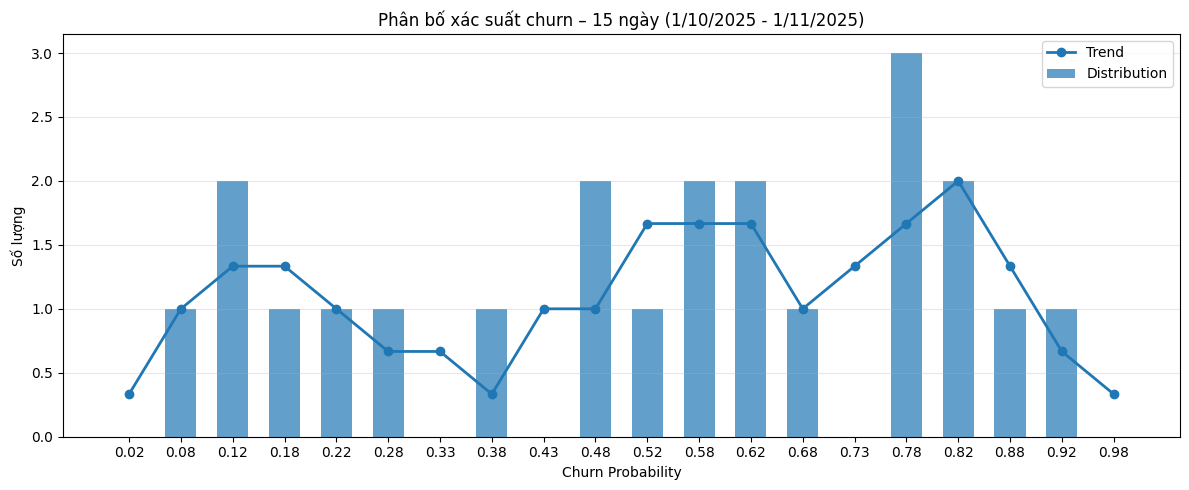

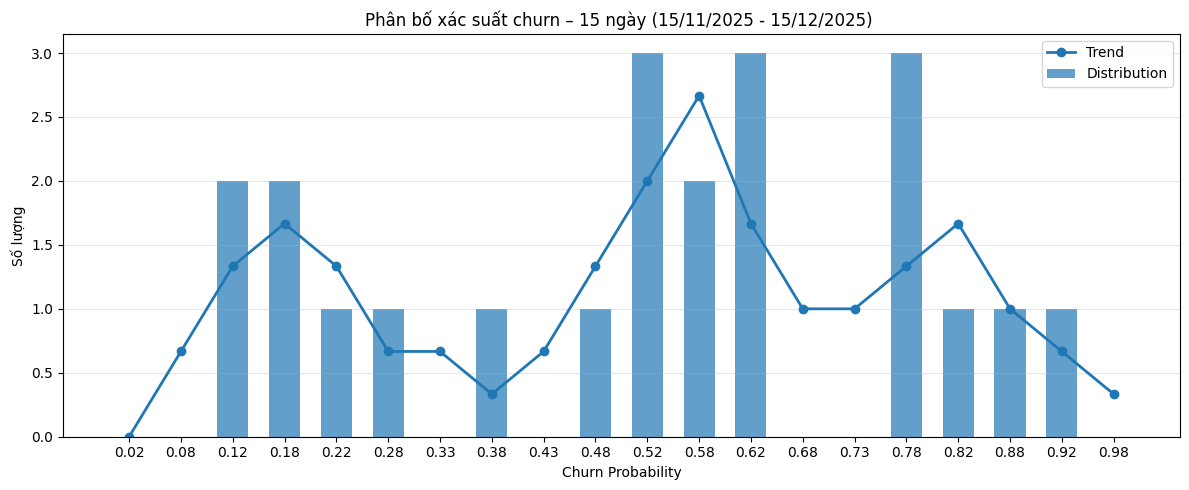

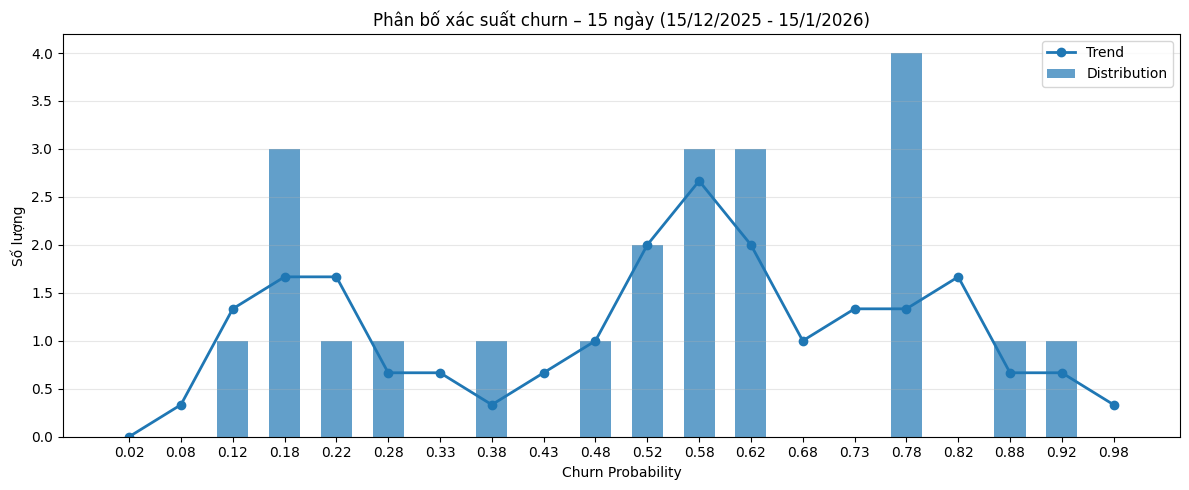

In [268]:
def plot_churn_hist_with_trend(
    df,
    proba_col,
    title,
    bins=20,
    smooth_window=3
):
    values = df[proba_col].values

    bins_edges = np.linspace(0, 1, bins + 1)
    bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2

    counts, _ = np.histogram(values, bins=bins_edges)

    def smooth(y, window=3):
        return np.convolve(y, np.ones(window) / window, mode="same")

    counts_smooth = smooth(counts, window=smooth_window)

    x = np.arange(len(bin_centers))

    plt.figure(figsize=(12, 5))

    plt.bar(
        x,
        counts,
        width=0.6,
        alpha=0.7,
        label="Distribution"
    )

    plt.plot(
        x,
        counts_smooth,
        marker="o",
        linewidth=2,
        label="Trend"
    )

    plt.xticks(x, np.round(bin_centers, 2))
    plt.xlabel("Churn Probability")
    plt.ylabel("Số lượng")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_churn_hist_with_trend(
    df_pred,
    "churn_proba_15d",
    "Phân bố xác suất churn – 15 ngày (1/10/2025 - 1/11/2025)"
)
plot_churn_hist_with_trend(
    df_pred15,
    "churn_proba_151d",
    "Phân bố xác suất churn – 15 ngày (15/11/2025 - 15/12/2025) "
)
plot_churn_hist_with_trend(
    df_pred15r,
    "churn_proba_15rd",
    "Phân bố xác suất churn – 15 ngày (15/12/2025 - 15/1/2026)"
)
# plot_churn_distribution(
#     df_pred30,
#     "churn_proba_30d",
#     "Phân bố xác suất churn – 30 ngày"
# )
# plot_churn_distribution(
#     df_pred301,
#     "churn_proba_301d",
#     "Phân bố xác suất churn – 30 ngày (non-churn)"
# )
# plot_churn_distribution(
#     df_pred30r,
#     "churn_proba_30rd",
#     "Phân bố xác suất churn – 30 ngày (return)"
# )

In [270]:
print("Số khách dự đoán 15d:", df_pred["spbiid"].nunique())
print("Số khách dự đoán 15d non churn:", df_pred15["spbiid"].nunique())
print("Số khách dự đoán 15d return:", df_pred15r["spbiid"].nunique())
# print("Số khách dự đoán 30d:", df_pred30["spbiid"].nunique())
# print("Số khách dự đoán 30d non churn:", df_pred301["spbiid"].nunique())
# print("Số khách dự đoán 30d return:", df_pred30r["spbiid"].nunique())


Số khách dự đoán 15d: 22
Số khách dự đoán 15d non churn: 22
Số khách dự đoán 15d return: 22


In [271]:
ALPHA = 0.35
BETA = 8
PRESSURE_CAP = 0.90

def layer2_time_pressure(
    df,
    r_base_col,        # churn_proba_15d / 30d / 45d
    delay_col,         # delaybinnoise
    out_col            # r_after_layer2_xxd
):
    df = df.copy()

    d = df[delay_col]

    pressure = 1 / (1 + np.exp(-BETA * (d - 1)))
    pressure = pressure.clip(0, PRESSURE_CAP)

    df["time_pressure"] = pressure

    df[out_col] = (
        df[r_base_col]
        + ALPHA * pressure * (1 - df[r_base_col])
    )

    df[out_col] = df[out_col].clip(0, 1)

    return df




In [272]:

gamma_map = {
    0: 0.0,
    1: 0.05,
    2: 0.10,
    "gt2": 0.15
}
def layer3_return_adjustment(
    df,
    r_layer2_col,     # r_after_layer2_xxd
    return_col,       # returnamount
    out_col           # churn_proba_final_xxd
):
    df = df.copy()

    def get_gamma(x):
        if x <= 0:
            return gamma_map[0]
        elif x == 1:
            return gamma_map[1]
        elif x == 2:
            return gamma_map[2]
        else:
            return gamma_map["gt2"]

    df["return_gamma"] = df[return_col].apply(get_gamma)

    df[out_col] = df[r_layer2_col] * (1 - df["return_gamma"])
    df[out_col] = df[out_col].clip(0, 1)

    return df

# ===== 15 DAYS =====
df_pred = layer2_time_pressure(
    df_pred,
    r_base_col="churn_proba_15d",
    delay_col="delaybinnoise",
    out_col="r_after_layer2_15d"
)

df_pred = layer3_return_adjustment(
    df_pred,
    r_layer2_col="r_after_layer2_15d",
    return_col="returnamount",
    out_col="churn_proba_final_15d"
)
# ===== 15 DAYS non churn =====
df_pred15 = layer2_time_pressure(
    df_pred15,
    r_base_col="churn_proba_151d",
    delay_col="delaybinnoise",
    out_col="r_after_layer2_151d"
)

df_pred15 = layer3_return_adjustment(
    df_pred15,
    r_layer2_col="r_after_layer2_151d",
    return_col="returnamount",
    out_col="churn_proba_final_151d"
)
# ===== 15 DAYS return =====
df_pred15r = layer2_time_pressure(
    df_pred15r,
    r_base_col="churn_proba_15rd",
    delay_col="delaybinnoise",
    out_col="r_after_layer2_15rd"
)

df_pred15r = layer3_return_adjustment(
    df_pred15r,
    r_layer2_col="r_after_layer2_15rd",
    return_col="returnamount",
    out_col="churn_proba_final_15rd"
)
# # ===== 30 DAYS =====
# df_pred30 = layer2_time_pressure(
#     df_pred30,
#     r_base_col="churn_proba_30d",
#     delay_col="delaybinnoise",
#     out_col="r_after_layer2_30d"
# )

# df_pred30 = layer3_return_adjustment(
#     df_pred30,
#     r_layer2_col="r_after_layer2_30d",
#     return_col="returnamount",
#     out_col="churn_proba_final_30d"
# )
# # ===== 30 DAYS =====
# df_pred301 = layer2_time_pressure(
#     df_pred301,
#     r_base_col="churn_proba_301d",
#     delay_col="delaybinnoise",
#     out_col="r_after_layer2_301d"
# )

# df_pred301 = layer3_return_adjustment(
#     df_pred301,
#     r_layer2_col="r_after_layer2_301d",
#     return_col="returnamount",
#     out_col="churn_proba_final_301d"
# )
# # ===== 30 DAYS =====
# df_pred30r = layer2_time_pressure(
#     df_pred30r,
#     r_base_col="churn_proba_30rd",
#     delay_col="delaybinnoise",
#     out_col="r_after_layer2_30rd"
# )

# df_pred30r = layer3_return_adjustment(
#     df_pred30r,
#     r_layer2_col="r_after_layer2_30rd",
#     return_col="returnamount",
#     out_col="churn_proba_final_30rd"
# )

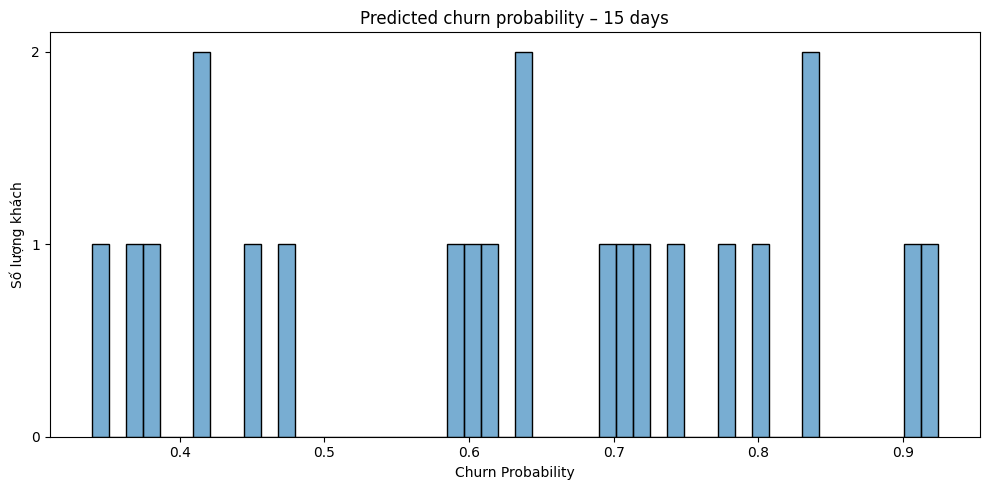

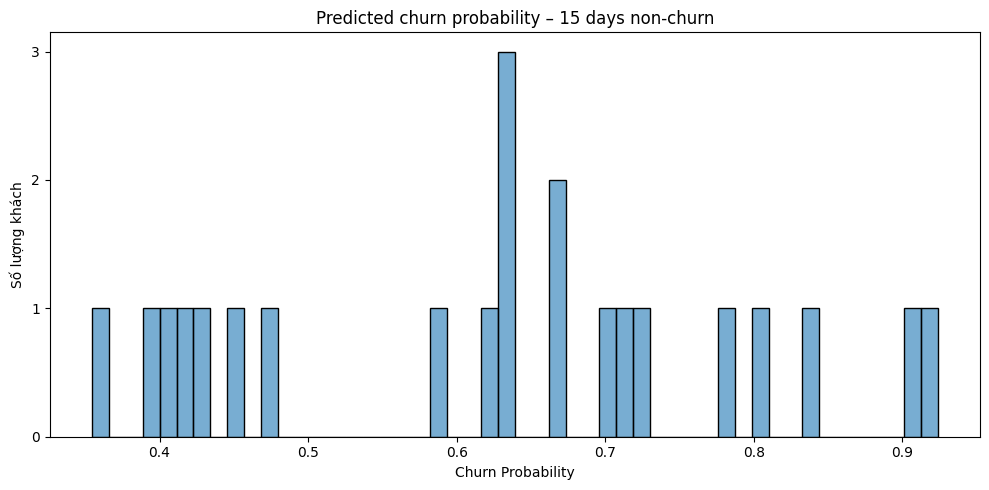

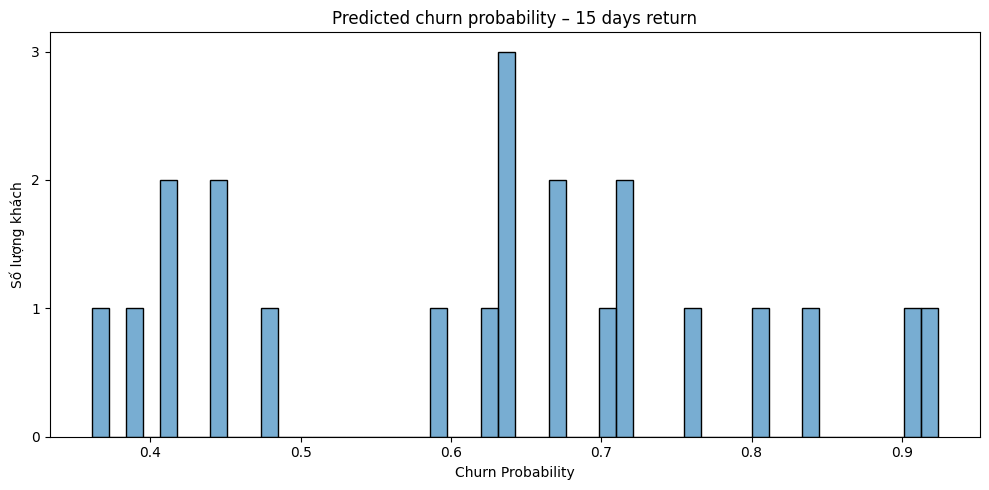

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_predicted_churn_distribution(df, proba_col, title):
    df_plot = df.sort_values(
        proba_col, ascending=False
    ).reset_index(drop=True)

    plt.figure(figsize=(10, 5))

    ax = sns.histplot(
        data=df_plot,
        x=proba_col,
        bins=50,
        kde=False,
        alpha=0.6
    )

    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xlabel("Churn Probability")
    plt.ylabel("Số lượng khách")
    plt.title(title)

    plt.tight_layout()
    plt.show()
plot_predicted_churn_distribution(
    df_pred,
    "churn_proba_final_15d",
    "Predicted churn probability – 15 days"
)

plot_predicted_churn_distribution(
    df_pred15,
    "churn_proba_final_151d",
    "Predicted churn probability – 15 days non-churn"
)

plot_predicted_churn_distribution(
    df_pred15r,
    "churn_proba_final_15rd",
    "Predicted churn probability – 15 days return"
)

# plot_predicted_churn_distribution(
#     df_pred30,
#     "churn_proba_final_30d",
#     "Predicted churn probability – 30 days"
# )
# plot_predicted_churn_distribution(
#     df_pred301,
#     "churn_proba_final_301d",
#     "Predicted churn probability – 30 days non-churn"
# )
# plot_predicted_churn_distribution(
#     df_pred30r,
#     "churn_proba_final_30rd",
#     "Predicted churn probability – 30 days return"
# )


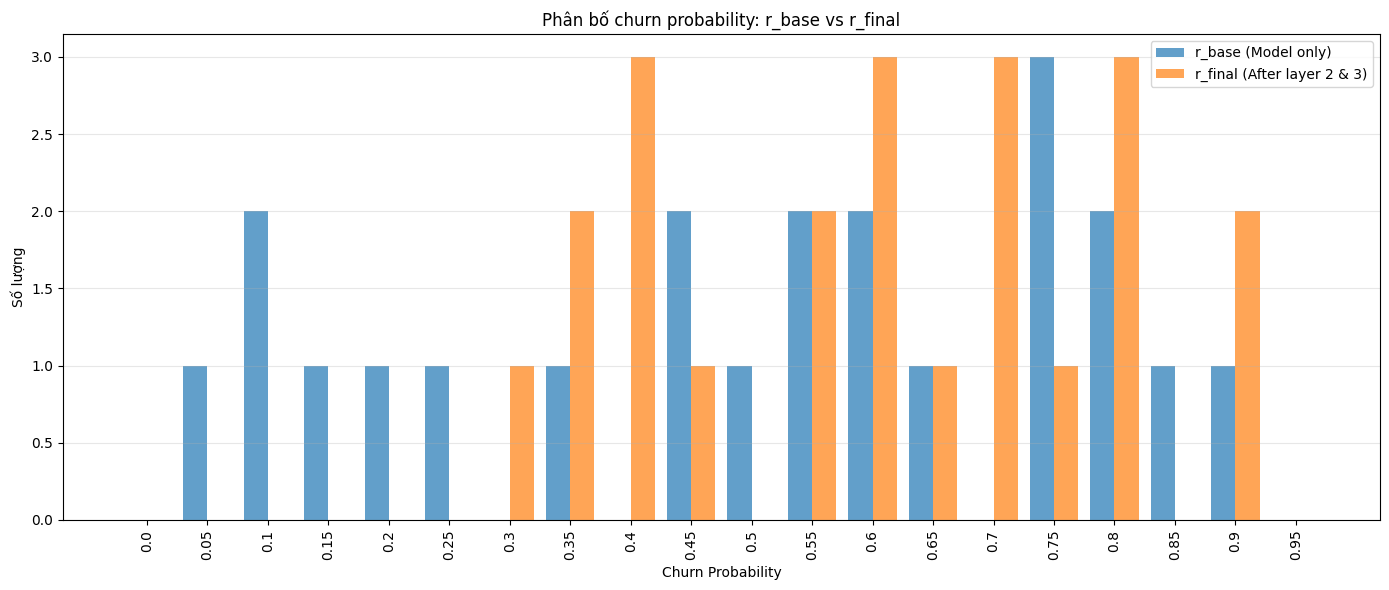

In [274]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bucket giống histogram rời rạc
bins = np.linspace(0, 1, 21)   # 0.0, 0.05, ..., 1.0
bin_labels = np.round(bins[:-1], 2)
df_pred["r_base_bin"] = pd.cut(
    df_pred["churn_proba_15d"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)

df_pred["r_final_bin"] = pd.cut(
    df_pred["churn_proba_final_15d"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
base_count = (
    df_pred["r_base_bin"]
    .value_counts()
    .sort_index()
)

final_count = (
    df_pred["r_final_bin"]
    .value_counts()
    .sort_index()
)

base_count = base_count.reindex(bin_labels, fill_value=0)
final_count = final_count.reindex(bin_labels, fill_value=0)
x = np.arange(len(bin_labels))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    base_count.values,
    width,
    label="r_base (Model only)",
    alpha=0.7
)

plt.bar(
    x + width/2,
    final_count.values,
    width,
    label="r_final (After layer 2 & 3)",
    alpha=0.7
)

plt.xticks(x, bin_labels, rotation=90)
plt.xlabel("Churn Probability")
plt.ylabel("Số lượng")
plt.title("Phân bố churn probability: r_base vs r_final")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


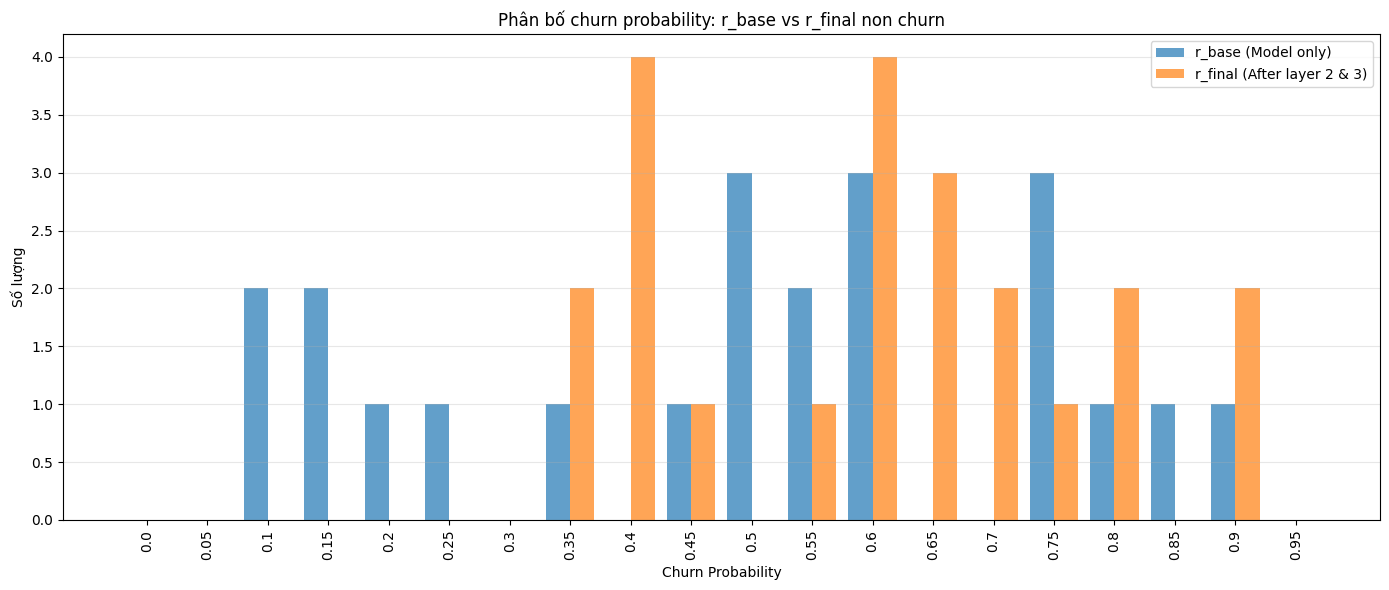

In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bucket giống histogram rời rạc
bins = np.linspace(0, 1, 21)   # 0.0, 0.05, ..., 1.0
bin_labels = np.round(bins[:-1], 2)
df_pred15["r_base_bin1"] = pd.cut(
    df_pred15["churn_proba_151d"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)

df_pred15["r_final_bin1"] = pd.cut(
    df_pred15["churn_proba_final_151d"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
base_count = (
    df_pred15["r_base_bin1"]
    .value_counts()
    .sort_index()
)

final_count = (
    df_pred15["r_final_bin1"]
    .value_counts()
    .sort_index()
)

base_count = base_count.reindex(bin_labels, fill_value=0)
final_count = final_count.reindex(bin_labels, fill_value=0)
x = np.arange(len(bin_labels))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    base_count.values,
    width,
    label="r_base (Model only)",
    alpha=0.7
)

plt.bar(
    x + width/2,
    final_count.values,
    width,
    label="r_final (After layer 2 & 3)",
    alpha=0.7
)

plt.xticks(x, bin_labels, rotation=90)
plt.xlabel("Churn Probability")
plt.ylabel("Số lượng")
plt.title("Phân bố churn probability: r_base vs r_final non churn")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


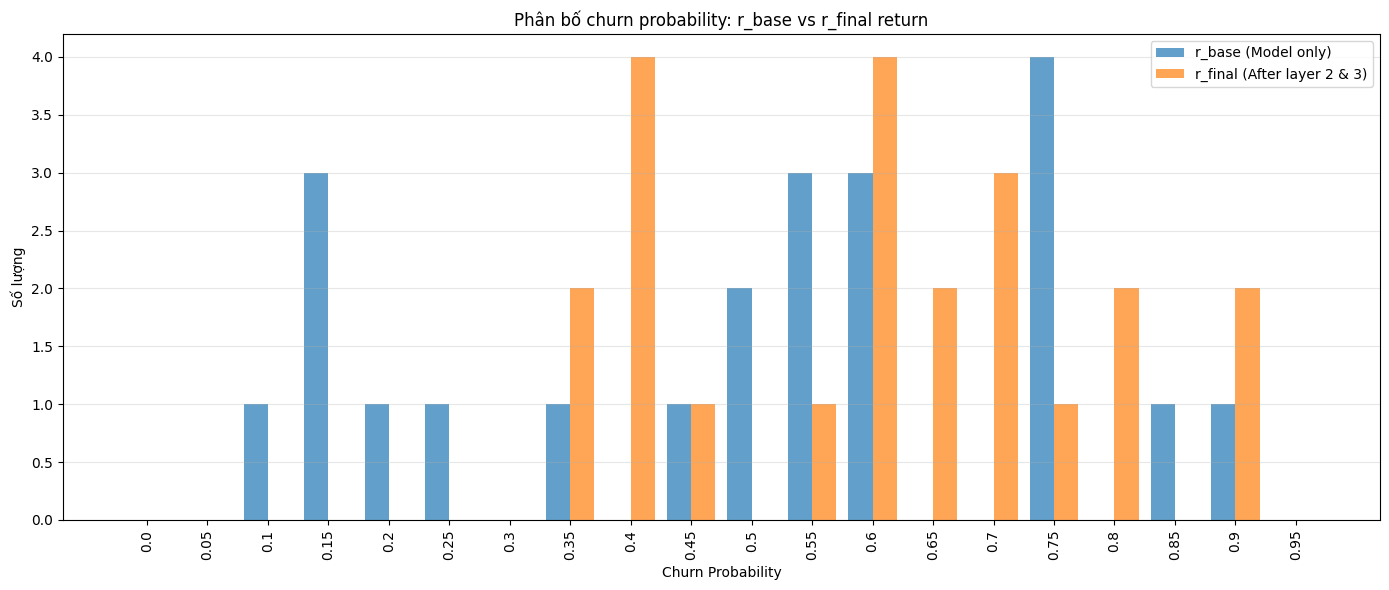

In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bucket giống histogram rời rạc
bins = np.linspace(0, 1, 21)   # 0.0, 0.05, ..., 1.0
bin_labels = np.round(bins[:-1], 2)
df_pred15r["r_base_bin"] = pd.cut(
    df_pred15r["churn_proba_15rd"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)

df_pred15r["r_final_bin"] = pd.cut(
    df_pred15r["churn_proba_final_15rd"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)
base_count = (
    df_pred15r["r_base_bin"]
    .value_counts()
    .sort_index()
)

final_count = (
    df_pred15r["r_final_bin"]
    .value_counts()
    .sort_index()
)

base_count = base_count.reindex(bin_labels, fill_value=0)
final_count = final_count.reindex(bin_labels, fill_value=0)
x = np.arange(len(bin_labels))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - width/2,
    base_count.values,
    width,
    label="r_base (Model only)",
    alpha=0.7
)

plt.bar(
    x + width/2,
    final_count.values,
    width,
    label="r_final (After layer 2 & 3)",
    alpha=0.7
)

plt.xticks(x, bin_labels, rotation=90)
plt.xlabel("Churn Probability")
plt.ylabel("Số lượng")
plt.title("Phân bố churn probability: r_base vs r_final return")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
